# E-Commerce Churn — Model Training & Evaluation

## Models Trained
- Logistic Regression
- Random Forest
- XGBoost

## Performance Comparison

| Model | AUC | F1 |
|------|-----|----|
| Logistic Regression | 0.7955 | 0.3744 |
| Random Forest | 0.9962 | 0.8789 |
| XGBoost | 0.9974 | 0.9536 |

## Key Findings
- XGBoost delivered the strongest churn prediction performance.
- Random Forest also achieved near-perfect separation.
- Logistic Regression served as a weaker linear baseline.
- ROC curve comparison visually confirmed XGBoost dominance.
- XGBoost feature importance validated EDA findings: Tenure, Complain, DaySinceLastOrder, Cashback-related variables, and SatisfactionScore were major churn drivers.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import(
classification_report,
confusion_matrix,
roc_auc_score,
roc_curve,
f1_score
)

In [4]:
df=pd.read_csv(r"C:\Users\Varsha\Downloads\churn_processed.csv")
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,is_new_customer,is_inactive,is_high_cashback,high_risk
0,50001,1,4.0,1,3,6.0,4,0,3.0,3,...,1,11.0,1.0,1.0,5.0,159.93,0,0,0,0
1,50002,1,9.0,2,1,8.0,6,1,3.0,4,...,1,15.0,0.0,1.0,0.0,120.90,0,0,0,0
2,50003,1,9.0,2,1,30.0,4,1,2.0,4,...,1,14.0,0.0,1.0,3.0,120.28,0,0,0,0
3,50004,1,0.0,2,3,15.0,4,1,2.0,4,...,0,23.0,0.0,1.0,3.0,134.07,1,0,0,0
4,50005,1,0.0,2,1,12.0,0,1,3.0,3,...,0,11.0,1.0,1.0,3.0,129.60,1,0,0,0


In [5]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [9]:
scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.fit_transform(X_test)

In [15]:
lr=LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=3000,
    solver='liblinear'
)

lr.fit(X_train,y_train)
print("Logistic Regression trained!")

Logistic Regression trained!


In [17]:
rf=RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train,y_train)
print("Random Forest trained")

Random Forest trained


In [18]:
scale_pos=(y_train==0).sum() / (y_train==1).sum()
scale_pos

np.float64(4.941952506596306)

In [19]:
xgb=XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train,y_train)
print("XGBoost trained!")

XGBoost trained!


In [20]:
def evaluate(name,model,X_data,y_data):
    y_pred=model.predict(X_data)
    y_prob=model.predict_proba(X_data)[:,1]

    auc=roc_auc_score(y_data,y_prob)
    f1=f1_score(y_data,y_pred)

    print(f"\n----- {name} -----")
    print("AUC Score:", round(auc,4))
    print("F1 Score:", round(f1,4))
    print(classification_report(y_data, y_pred))
    
    return auc, f1
    

In [21]:
lr_auc,lr_f1=evaluate("Logistic Regression",lr,X_test_sc,y_test)


----- Logistic Regression -----
AUC Score: 0.7955
F1 Score: 0.3744
              precision    recall  f1-score   support

           0       0.98      0.35      0.52       936
           1       0.23      0.97      0.37       190

    accuracy                           0.45      1126
   macro avg       0.61      0.66      0.44      1126
weighted avg       0.86      0.45      0.49      1126



C:\Users\Varsha\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\Varsha\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [22]:
rf_auc,rf_f1=evaluate("Random Forest",rf,X_test,y_test)


----- Random Forest -----
AUC Score: 0.9962
F1 Score: 0.8789
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       936
           1       0.95      0.82      0.88       190

    accuracy                           0.96      1126
   macro avg       0.96      0.91      0.93      1126
weighted avg       0.96      0.96      0.96      1126



In [23]:
xgb_auc,xgb_f1=evaluate("XGBoost",xgb,X_test,y_test)


----- XGBoost -----
AUC Score: 0.9974
F1 Score: 0.9536
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.93      0.97      0.95       190

    accuracy                           0.98      1126
   macro avg       0.96      0.98      0.97      1126
weighted avg       0.98      0.98      0.98      1126



C:\Users\Varsha\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


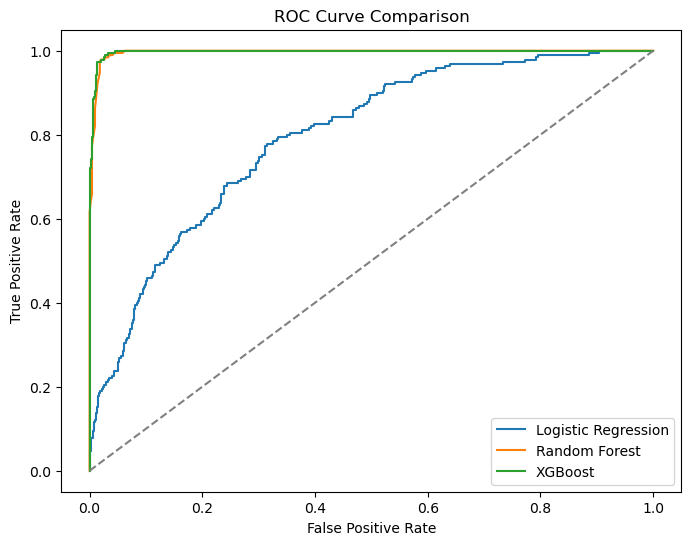

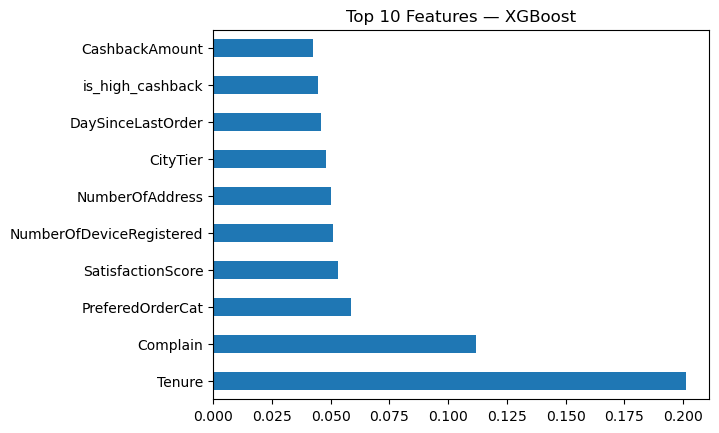

In [26]:
# ROC curves for all 3 models
plt.figure(figsize=(8,6))
for name, model, scaled in [
    ("Logistic Regression", lr, True),
    ("Random Forest", rf, False),
    ("XGBoost", xgb, False)]:
    X = X_test_sc if scaled else X_test
    fpr, tpr, _ = roc_curve(y_test,
                             model.predict_proba(X)[:,1])
    plt.plot(fpr, tpr, label=name)
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# XGBoost feature importance
feat_imp = pd.Series(xgb.feature_importances_,
                      index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features — XGBoost')
plt.show()